
Generated 375 customer data points


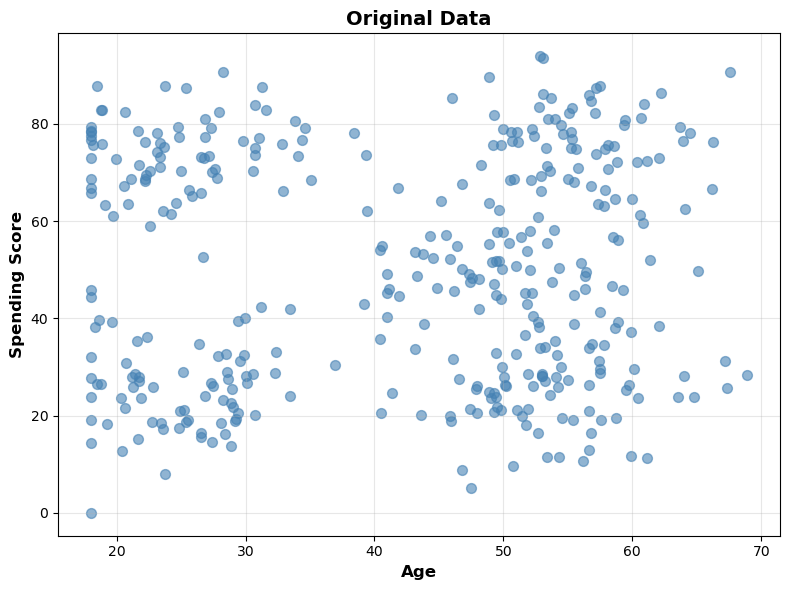

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# ==================== DATA GENERATION ====================

def generate_data(n_samples=300, noise_level=0.5, random_state=42):
    """Generate customer data: Age vs Spending Score"""
    np.random.seed(random_state)
    
    cov = [[20 * (1 + noise_level), 5], [5, 40 * (1 + noise_level)]]
    
    c1 = np.random.multivariate_normal([25, 75], cov, n_samples//4)
    c2 = np.random.multivariate_normal([25, 25], cov, n_samples//4)
    c3 = np.random.multivariate_normal([55, 75], cov, n_samples//4)
    c4 = np.random.multivariate_normal([55, 25], cov, n_samples//4)
    c5 = np.random.multivariate_normal([50, 50], cov, n_samples//4)
    
    data = np.vstack([c1, c2, c3, c4, c5])
    data[:, 0] = np.clip(data[:, 0], 18, 70)
    data[:, 1] = np.clip(data[:, 1], 0, 100)
    
    return data


# ==================== VISUALIZATION ====================

def plot_clusters(X, labels, title):
    """Plot clustering results"""
    plt.figure(figsize=(10, 7))
    
    unique_labels = set(labels)
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(sorted(unique_labels)):
        if label == -1:
            # Noise points (DBSCAN only)
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], 
                       c='black', alpha=0.3, s=30, marker='x', label='Noise')
        else:
            mask = labels == label
            plt.scatter(X[mask, 0], X[mask, 1], 
                       c=[colors[i]], alpha=0.6, s=50,
                       label=f'Cluster {label}', edgecolors='black', linewidth=0.5)
    
    plt.xlabel('Age', fontsize=12, fontweight='bold')
    plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==================== AGGLOMERATIVE CLUSTERING ====================

def apply_agglomerative(X, n_clusters=4, linkage_type='ward'):
    """Apply Agglomerative Clustering"""
    print(f"\nAgglomerative Clustering (linkage={linkage_type}):")
    
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_type)
    labels = model.fit_predict(X)
    
    # Print cluster sizes
    for i in range(n_clusters):
        count = np.sum(labels == i)
        print(f"  Cluster {i}: {count} points")
    
    return labels


def plot_dendrogram(X, method='ward'):
    """Plot dendrogram"""
    plt.figure(figsize=(12, 6))
    Z = linkage(X, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
    plt.xlabel('Cluster Index', fontsize=12, fontweight='bold')
    plt.ylabel('Distance', fontsize=12, fontweight='bold')
    plt.title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ==================== DBSCAN ====================

def apply_dbscan(X, eps=5, min_samples=5):
    """Apply DBSCAN Clustering"""
    print(f"\nDBSCAN (eps={eps}, min_samples={min_samples}):")
    
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"  Number of clusters: {n_clusters}")
    print(f"  Noise points: {n_noise}")
    
    for label in sorted(set(labels)):
        if label != -1:
            count = np.sum(labels == label)
            print(f"  Cluster {label}: {count} points")
    
    return labels


# ==================== MAIN ====================


# Generate data
data = generate_data(n_samples=300, noise_level=0.75, random_state=42)
print(f"\nGenerated {len(data)} customer data points")

# Visualize original data
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c='steelblue', alpha=0.6, s=50)
plt.xlabel('Age', fontsize=12, fontweight='bold')
plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
plt.title('Original Data', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




AGGLOMERATIVE CLUSTERING


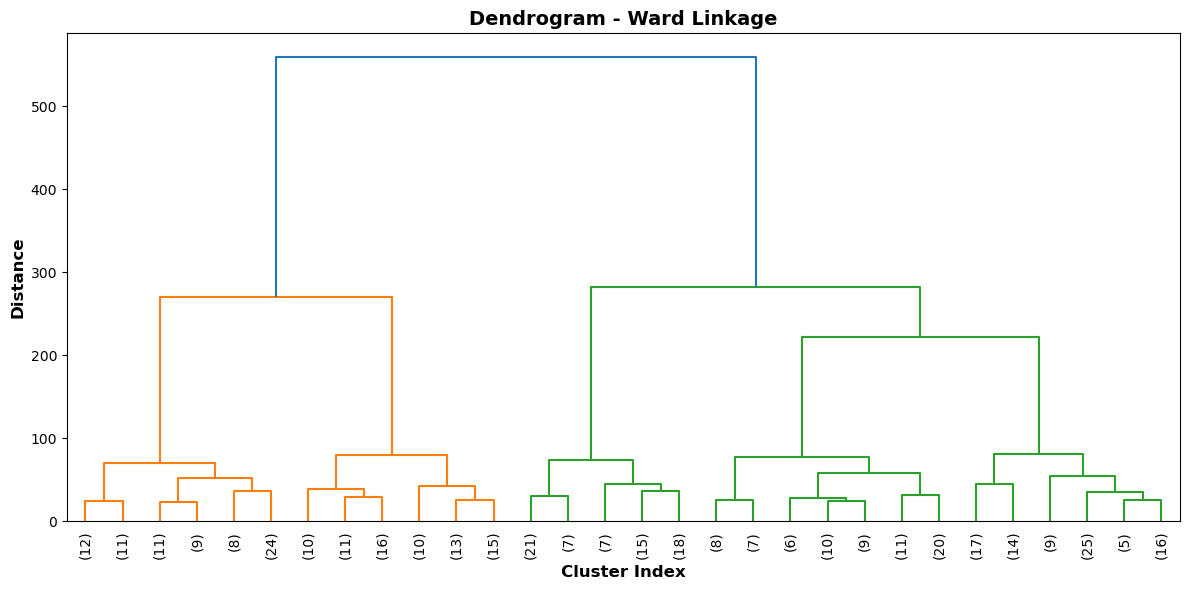


Agglomerative Clustering (linkage=ward):
  Cluster 0: 86 points
  Cluster 1: 75 points
  Cluster 2: 68 points
  Cluster 3: 75 points
  Cluster 4: 71 points


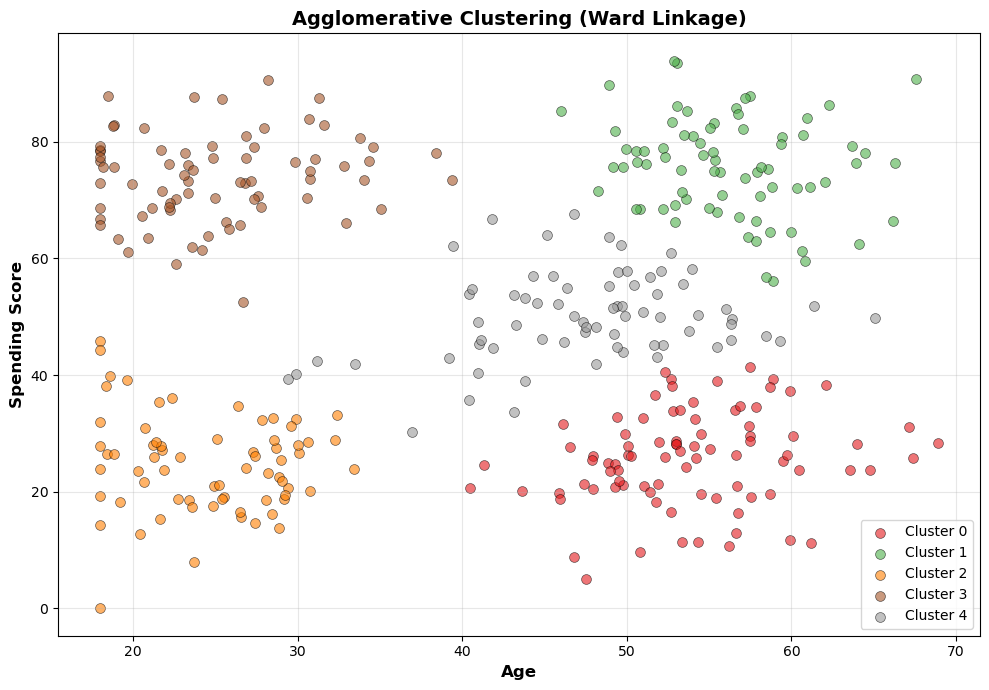

In [2]:
# ==================== AGGLOMERATIVE CLUSTERING ====================
print("\n" + "="*60)
print("AGGLOMERATIVE CLUSTERING")
print("="*60)

# Show dendrogram
plot_dendrogram(data, method='ward')

# Apply clustering
labels_agg = apply_agglomerative(data, n_clusters=5, linkage_type='ward')
plot_clusters(data, labels_agg, 'Agglomerative Clustering (Ward Linkage)')





DBSCAN

DBSCAN (eps=5, min_samples=5):
  Number of clusters: 3
  Noise points: 23
  Cluster 0: 70 points
  Cluster 1: 65 points
  Cluster 2: 217 points


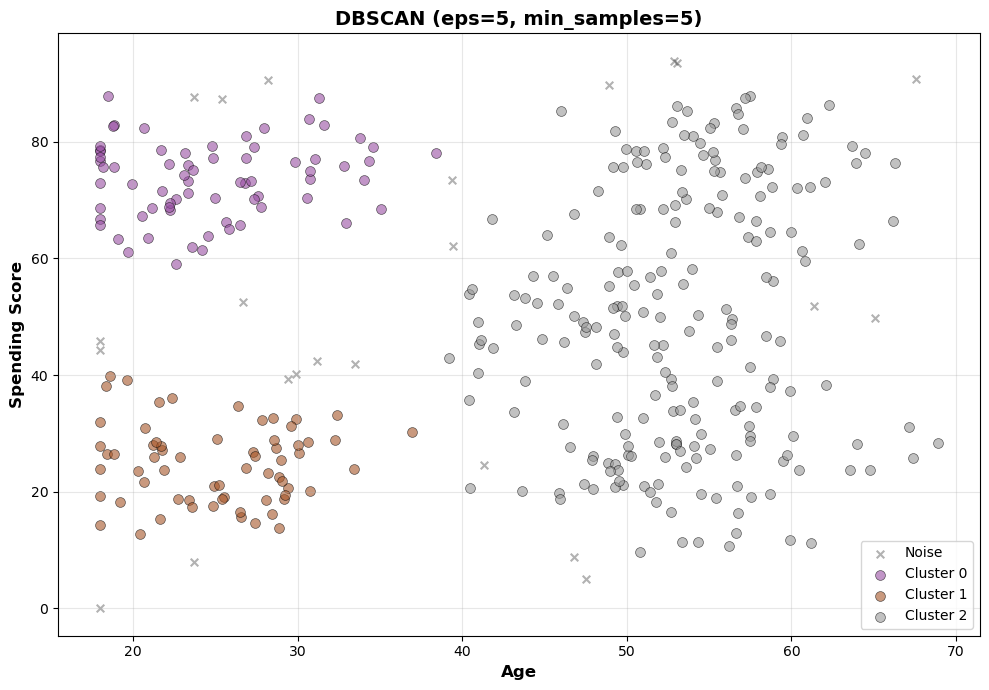

In [3]:
# ==================== DBSCAN ====================
print("\n" + "="*60)
print("DBSCAN")
print("="*60)

# Apply DBSCAN
labels_dbscan = apply_dbscan(data, eps=5, min_samples=5)
plot_clusters(data, labels_dbscan, 'DBSCAN (eps=5, min_samples=5)')
